# Exploratory Data Analysis (EDA)
In this notebook, we'll perform an exploratory data analysis on the `legislative_trades.csv` dataset, which contains House and Senate stock trading disclosures.
We'll explore:
- The structure and missing values of the data
- Who the most active traders are
- What the most popular assets/tickers are
- The distribution of transaction sizes

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress annoying future warnings
warnings.filterwarnings('ignore')

# Set plotting styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")

## 2. Load Dataset
Let's bring in the structured CSV file we generated during our data pipeline phase and set up `transaction_date` as a proper datetime object.

In [2]:
df = pd.read_csv('../data/legislative_trades.csv')
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
df['disclosure_date'] = pd.to_datetime(df['disclosure_date'], errors='coerce')
df.head()

,chamber,legislator_name,transaction_date,disclosure_date,ticker,asset_description,asset_type,transaction_type,amount_range,amount_min,amount_max,amount_avg,owner,ptr_link,office,party,state,transaction_year,disclosure_year,comment
0,Senate,Ron L Wyden,2020-11-10,NaT,BYND,"Beyond Meat, Inc.",Stock,Sale,"$50,001 - $100,000",50001.0,100000.0,75000.5,Spouse,https://efdsearch.senate.gov/search/view/ptr/a...,NaN,NaN,NaN,2020,NaN,--
1,Senate,Pat Roberts,2020-11-16,NaT,BA,The Boeing Company,Stock,Purchase,"$15,001 - $50,000",15001.0,50000.0,32500.5,Spouse,https://efdsearch.senate.gov/search/view/ptr/b...,NaN,NaN,NaN,2020,NaN,R
2,Senate,Pat Roberts,2020-11-16,NaT,V,Visa Inc.,Stock,Purchase,"$15,001 - $50,000",15001.0,50000.0,32500.5,Spouse,https://efdsearch.senate.gov/search/view/ptr/b...,NaN,NaN,NaN,2020,NaN,555
3,Senate,Pat Roberts,2020-11-24,NaT,COST,Costco Wholesale Corporation,Stock,Purchase,"$15,001 - $50,000",15001.0,50000.0,32500.5,Spouse,https://efdsearch.senate.gov/search/view/ptr/b...,NaN,NaN,NaN,2020,NaN,555
4,Senate,Pat Roberts,2020-11-04,NaT,COST,Costco Wholesale Corporation,Stock,Sale,"$15,001 - $50,000",15001.0,50000.0,32500.5,Spouse,https://efdsearch.senate.gov/search/view/ptr/b...,NaN,NaN,NaN,2020,NaN,555


## 3. Initial Data Inspection
Let's see the overall dataset dimensions and observe for missing entries (which is typical from unstructured PDF texts).

In [3]:
print(f"Dataset shape: {df.shape}\\n")
print(df.info())
print("\\nMissing Values:")
print(df.isnull().sum())

Dataset shape: (16202, 20)\n
<class 'pandas.DataFrame'>
RangeIndex: 16202 entries, 0 to 16201
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   chamber            16202 non-null  str           
 1   legislator_name    16202 non-null  str           
 2   transaction_date   16202 non-null  datetime64[us]
 3   disclosure_date    14847 non-null  datetime64[us]
 4   ticker             12328 non-null  str           
 5   asset_description  16202 non-null  str           
 6   asset_type         1355 non-null   str           
 7   transaction_type   15626 non-null  str           
 8   amount_range       16202 non-null  str           
 9   amount_min         1337 non-null   float64       
 10  amount_max         1337 non-null   float64       
 11  amount_avg         1337 non-null   float64       
 12  owner              8708 non-null   str           
 13  ptr_link           16202 non-null  str     

## 4. Univariate Analysis
Who trades the most? What variables trade the most? How are transaction sizes distributed?

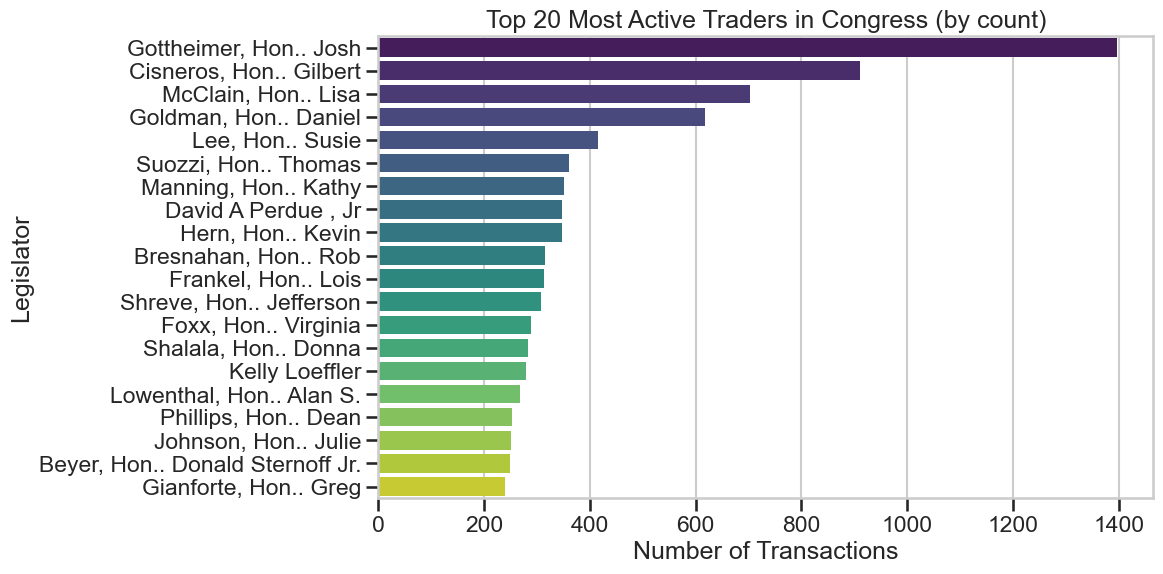

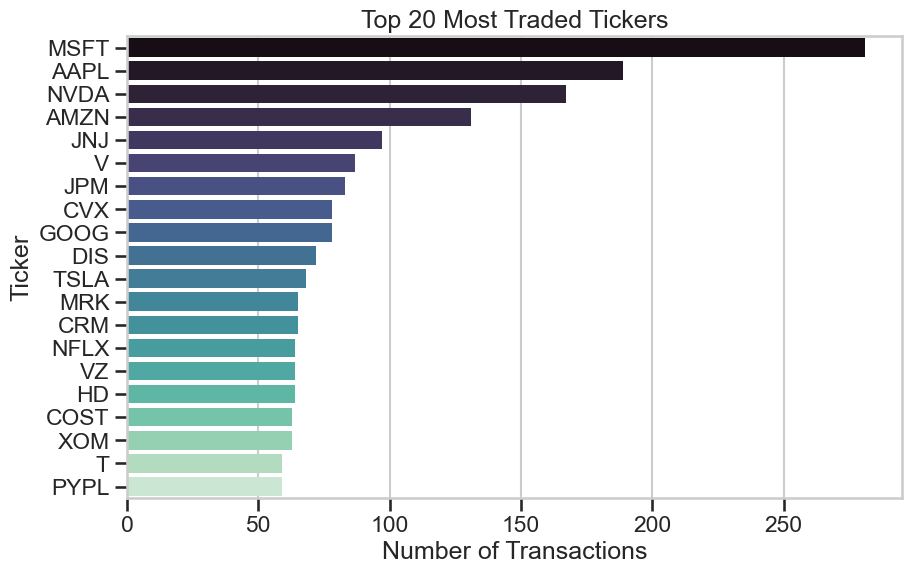

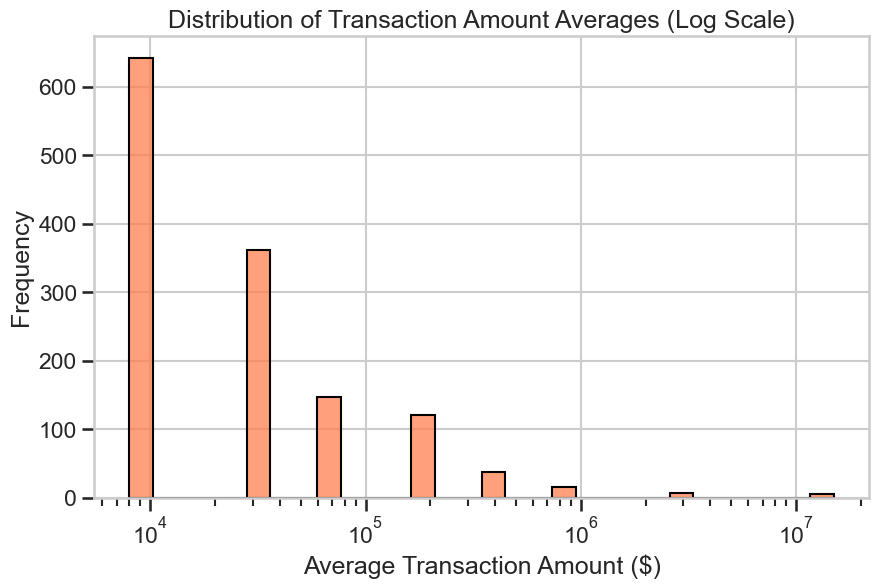

In [4]:
# Top 20 most active traders
plt.figure(figsize=(10, 6))
top_traders = df['legislator_name'].value_counts().head(20)
sns.barplot(y=top_traders.index, x=top_traders.values, palette='viridis')
plt.title('Top 20 Most Active Traders in Congress (by count)')
plt.xlabel('Number of Transactions')
plt.ylabel('Legislator')
plt.show()

# Top 20 most traded tickers (ignoring nulls)
plt.figure(figsize=(10, 6))
top_tickers = df[df['ticker'].notna()]['ticker'].value_counts().head(20)
sns.barplot(y=top_tickers.index, x=top_tickers.values, palette='mako')
plt.title('Top 20 Most Traded Tickers')
plt.xlabel('Number of Transactions')
plt.ylabel('Ticker')
plt.show()

# Transaction Amount Distribution
# Use log scale since ranges jump from a few thousand to multi-million mathematically
plt.figure(figsize=(10, 6))
sns.histplot(data=df.dropna(subset=['amount_avg']), x='amount_avg', bins=30, log_scale=True, color='coral')
plt.title('Distribution of Transaction Amount Averages (Log Scale)')
plt.xlabel('Average Transaction Amount ($)')
plt.ylabel('Frequency')
plt.show()

## 5. Bivariate and Multivariate Analysis
We can observe how trading behavior changed over time (per year and per month), as well as split behavior across chambers.

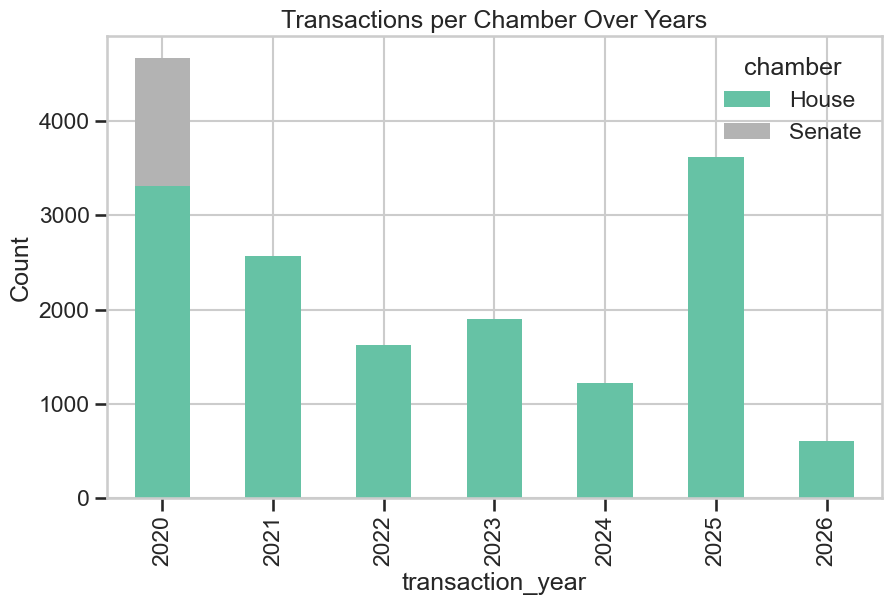

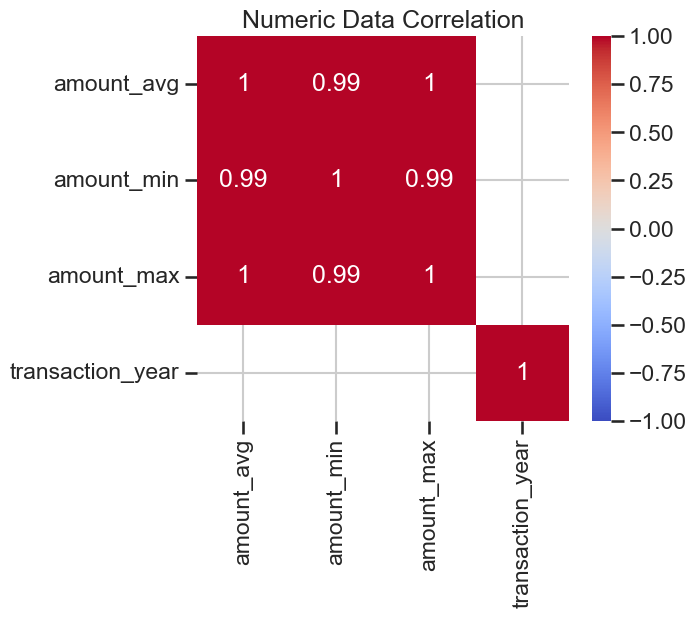

In [5]:
# Transactions over Time
by_year = df.groupby(['transaction_year', 'chamber']).size().unstack().fillna(0)
by_year.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set2')
plt.title('Transactions per Chamber Over Years')
plt.ylabel('Count')
plt.show()

# Heatmap looking for explicit gaps/coverage issues between amounts and years
import seaborn as sns
corr = df[['amount_avg', 'amount_min', 'amount_max', 'transaction_year']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Numeric Data Correlation')
plt.show()

## 6. Data Cleaning and Feature Engineering
Let's clean out unparsed dates to prep for financial integrations and introduce features like the delayed transaction time.

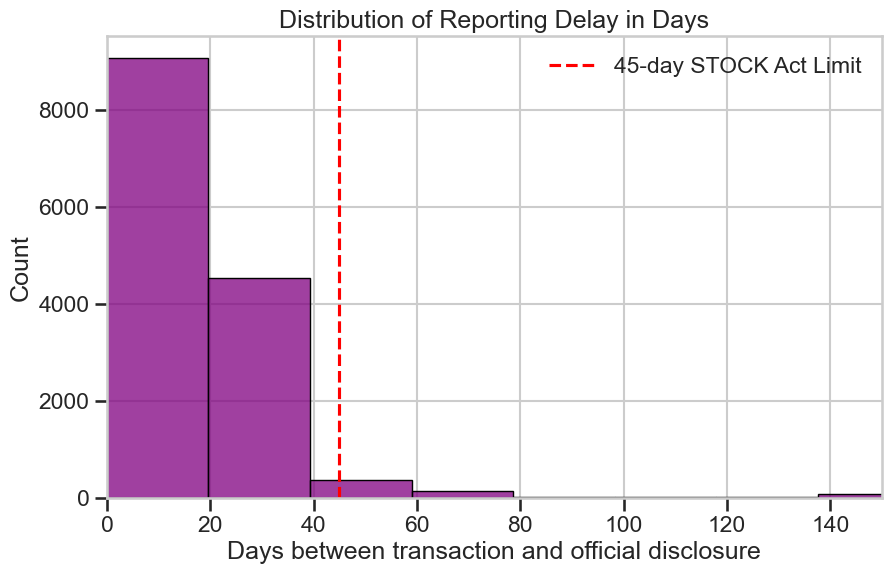

Final analysis set size directly applicable to Yahoo Finance: 11061 rows


In [6]:
# Feature Engineering: Delay between transaction and disclosure
df['reporting_delay_days'] = (df['disclosure_date'] - df['transaction_date']).dt.days

# Data Cleaning: Remove severe outliers/negatives due to bad OCR dates
clean_df = df[(df['reporting_delay_days'] >= 0) & (df['reporting_delay_days'] < 1000)]

plt.figure(figsize=(10, 6))
sns.histplot(data=clean_df, x='reporting_delay_days', bins=50, color='purple')
plt.title('Distribution of Reporting Delay in Days')
plt.xlabel('Days between transaction and official disclosure')
plt.xlim(0, 150) # The STOCK ACT technically requires 45 days
plt.axvline(45, color='red', linestyle='--', label='45-day STOCK Act Limit')
plt.legend()
plt.show()

# Drop completely unidentifiable ticker properties to ready it for the next phase
financial_df = clean_df.dropna(subset=['ticker']).copy()
financial_df['ticker'] = financial_df['ticker'].str.strip()

print(f"Final analysis set size directly applicable to Yahoo Finance: {len(financial_df)} rows")

## The "Heavy Hitters": Animated Racing Bar Chart
Let's analyze who drives the most volume by total cumulative trades over time. This animated visual tracks the top 10 most active congressional traders month-by-month.

In [ ]:
import pandas as pd
import plotly.express as px
import numpy as np

# Reload or make sure we have a clean copy to work with
df_trades = pd.read_csv('../data/legislative_trades.csv', skipinitialspace=True)
df_trades.columns = df_trades.columns.str.strip()
df_trades['legislator_name'] = df_trades['legislator_name'].str.strip()
df_trades['transaction_date'] = pd.to_datetime(df_trades['transaction_date'], errors='coerce')

# Parse amount_avg from amount_range for any missing values directly in notebook
def _parse_amount(value):
    if pd.isna(value):
        return np.nan
    s = str(value).strip().replace('$', '').replace(',', '').lower()
    if ' - ' in s:
        try:
            lo, hi = s.split(' - ', 1)
            return (float(lo) + float(hi)) / 2
        except ValueError:
            pass
    elif s.endswith('+'):
        try:
            return float(s[:-1])
        except ValueError:
            pass
    try:
        return float(s)
    except ValueError:
        pass
    return np.nan

missing_avg_mask = df_trades['amount_avg'].isna()
df_trades.loc[missing_avg_mask, 'amount_avg'] = df_trades.loc[missing_avg_mask, 'amount_range'].apply(_parse_amount)

# Drop invalid dates/amounts
df_valid_trades = df_trades.dropna(subset=['transaction_date', 'amount_avg', 'legislator_name']).copy()

# Sort by date
df_valid_trades.sort_values('transaction_date', inplace=True)

# Filter out dates before MIN_YEAR and absurd futures
df_valid_trades = df_valid_trades[(df_valid_trades['transaction_date'].dt.year >= 2018) & (df_valid_trades['transaction_date'].dt.year <= 2026)]

# Build a Year-Month string to group periods smoothly
df_valid_trades['YearMonth'] = df_valid_trades['transaction_date'].dt.to_period('M').astype(str)

# 1. Sum trade amounts (Buys/Sells together as gross activity) per month for everyone
monthly_volume = df_valid_trades.groupby(['YearMonth', 'legislator_name'])['amount_avg'].sum().reset_index()

# 2. Pivot the data to get a column for every politician per month and fill in zeroes
pivot_df = monthly_volume.pivot(index='YearMonth', columns='legislator_name', values='amount_avg').fillna(0)

# 3. Calculate running cumulative sum month-over-month
cumulative_df = pivot_df.cumsum()

# 4. Turn the data back into a long format, suitable for plotly animations
melted_df = cumulative_df.reset_index().melt(id_vars='YearMonth', var_name='legislator_name', value_name='Cumulative_Volume')

# 5. Extract only the Top 10 per month and calculate Rank
top_n_frames = []
all_months = sorted(melted_df['YearMonth'].unique())

for month in all_months:
    group = melted_df[melted_df['YearMonth'] == month]
    # Get top 10 traders this month
    top_group = group.nlargest(10, 'Cumulative_Volume').copy()
    
    # Generate continuous ranks (1 is top, 10 is bottom for the month)
    top_group['Rank'] = top_group['Cumulative_Volume'].rank(method='first', ascending=False)
    # Give it a string category representation
    top_group['Rank_Str'] = "Rank " + top_group['Rank'].astype(int).astype(str).str.zfill(2)
    top_n_frames.append(top_group)

racing_df = pd.concat(top_n_frames)

# Ensure chronological and rank ordering
racing_df.sort_values(by=['YearMonth', 'Rank'], inplace=True)

# Create a stable list of colors so the politicians don't flash randomly
unique_traders = racing_df['legislator_name'].unique()

# Create the Animated Racing Bar Chart!
# We use 'Rank_Str' as a categorical Y-axis that stays stable while 'legislator_name' changes per Rank over time
fig = px.bar(
    racing_df,
    x='Cumulative_Volume',
    y='Rank_Str',
    color='legislator_name',
    text='legislator_name',
    animation_frame='YearMonth',
    animation_group='legislator_name',
    category_orders={'Rank_Str': [f"Rank {str(i).zfill(2)}" for i in range(1, 11)],
                     'YearMonth': all_months,
                     'legislator_name': list(unique_traders)},
    title='Who is Driving Trade Volume? (Top 10 Congressional Traders Over Time)',
    labels={'Cumulative_Volume': 'Total Estimated Volume ($)', 'Rank_Str': ''},
    hover_data={'Cumulative_Volume': ':$,.0f'},
    height=600
)

# Cosmetic layout updates
fig.update_traces(textposition='inside', insidetextanchor='start')
fig.update_layout(
    xaxis=dict(title='Cumulative Gross Trading Volume ($)'),
    yaxis=dict(autorange="reversed"), # Top rank at the top
    showlegend=False,
    margin=dict(r=50),
    barmode='overlay'
)

# Note: Sometimes animations in Jupyter need to be bounded correctly, this locks the x-axis scale
max_vol = racing_df['Cumulative_Volume'].max() * 1.05
fig.update_layout(xaxis_range=[0, max_vol])

fig.show()

## Export for Flourish Studio (Racing Bar Chart)
Flourish expects data in a "Wide" format where each row is an entity (a politician), and each column is a point in time (the months), displaying the cumulative value at that time. We'll also extract their `party` affiliation so you can color-code the bars automatically (e.g., Blue for Democrats, Red for Republicans).

In [11]:
# We already have `cumulative_df` built exactly for this! 
# We just need to pivot it back so the Politicians are rows and the Months are columns
import os

# Ensure the output directory exists
os.makedirs('../data/', exist_ok=True)

# 1. Transpose the dataframe
flourish_df = cumulative_df.T.reset_index()

# 2. Clean the messy names for Flourish (e.g. "Gottheimer, Hon.. Josh" -> "Josh Gottheimer")
def clean_names_for_flourish(name):
    if pd.isna(name):
        return name
    name = str(name).strip()
    if ', Hon..' in name:
        parts = name.split(', Hon..')
        name = f"{parts[1].strip()} {parts[0].strip()}"
    elif ', Hon.' in name:
        parts = name.split(', Hon.')
        name = f"{parts[1].strip()} {parts[0].strip()}"
    
    # Strip formal titles and noise
    name = name.replace("Hon..", "").replace("Hon.", "").replace("Mrs..", "").replace("Mrs.", "")
    name = name.replace("Mr..", "").replace("Mr.", "").replace("Dr.", "").replace("Dr ", " ")
    name = name.replace("MD", "").replace("FACS", "").replace(",", "").replace('"', '')
    name = " ".join(name.split())
    
    # Handle "Last First" generated due to absent commas
    parts = name.split()
    if len(parts) == 2 and parts[0] in ["Fields", "Newman", "Manning", "Meijer", "Spartz", "Ross"]:
        name = f"{parts[1]} {parts[0]}"
        
    return name

flourish_df['legislator_name'] = flourish_df['legislator_name'].apply(clean_names_for_flourish)

# 3. Hardcode the party affiliation for most notable traders in the dataset
hardcoded_parties = {
    # Senate
    "A. Mitchell Mcconnell Jr.": "Republican", "Angus S King Jr.": "Independent", "Christopher A Coons": "Democrat",
    "Daniel S Sullivan": "Republican", "David A Perdue Jr": "Republican", "Gary C Peters": "Democrat",
    "Jacklyn S Rosen": "Democrat", "James M Inhofe": "Republican", "Jerry Moran": "Republican",
    "John Hoeven": "Republican", "Kelly Loeffler": "Republican", "Mark R Warner": "Democrat",
    "Michael F Bennet": "Democrat", "Pat Roberts": "Republican", "Patrick J Toomey": "Republican",
    "Rick Scott": "Republican", "Ron Johnson": "Republican", "Ron L Wyden": "Democrat",
    "Sheldon Whitehouse": "Democrat", "Shelley M Capito": "Republican", "Susan M Collins": "Republican",
    "Thomas R Carper": "Democrat", "Tina Smith": "Democrat", "William Cassidy": "Republican",
    
    # House Top Traders 
    "Josh Gottheimer": "Democrat", "Darrell E. Issa": "Republican", "Nancy Pelosi": "Democrat",
    "Suzan K. DelBene": "Democrat", "Mark Green": "Republican", "Kevin Hern": "Republican",
    "Scott H. Peters": "Democrat", "David Trone": "Democrat", "Daniel Goldman": "Democrat",
    "Marie Newman": "Democrat", "Carol Devine Miller": "Republican", "Marjorie Taylor Greene": "Republican",
    "Greene Marjorie Taylor": "Republican", "Michael Thomas McCaul": "Republican", "Virginia Foxx": "Republican",
    "Gilbert Cisneros": "Democrat", "Marie Gluesenkamp Perez": "Democrat", "Ro Khanna": "Democrat",
    "Jefferson Shreve": "Republican", "Donald Sternoff Jr. Beyer": "Democrat", "Patrick Fallon": "Republican",
    "Greg Gianforte": "Republican", "Kathy Manning": "Democrat", "Thomas Suozzi": "Democrat",
    "Cleo Fields": "Democrat", "Tim Moore": "Republican", "Sheri Biggs": "Republican", "Lisa McClain": "Republican",
    "Kim Schrier": "Democrat", "Richard W. Allen": "Republican", "K. Michael Conaway": "Republican",
    "John W. Rose": "Republican", "Susie Lee": "Democrat", "Earl Leroy Carter": "Republican",
    "Rob Bresnahan": "Republican", "Earl Blumenauer": "Democrat", "Dan Daniel Bishop": "Republican",
    "Nicholas V. Taylor": "Republican", "James R. Langevin": "Democrat", "Scott Scott Franklin": "Republican",
    "Tom Malinowski": "Democrat", "Christopher L. Jacobs": "Republican", "Maria Elvira Salazar": "Republican",
    "Donna Shalala": "Democrat", "Dean Phillips": "Democrat", "Peter Meijer": "Republican",
    "Vern Buchanan": "Republican", "Lois Frankel": "Democrat", "Pete Sessions": "Republican",
    "Katherine M. Clark": "Democrat", "Jonathan Jackson": "Democrat", "Alan S. Lowenthal": "Democrat",
    "Julie Johnson": "Democrat", "Jared Moskowitz": "Democrat", "George Whitesides": "Democrat",
    "Daniel Meuser": "Republican", "Sara Jacobs": "Democrat", "Jacobs Sara": "Democrat",
    "C. Scott Franklin": "Republican", "Valerie Hoyle": "Democrat", "Kelly Louise Morrison": "Democrat",
    "Brad Sherman": "Democrat", "Greg Landsman": "Democrat", "John Curtis": "Republican",
    "Mike Kelly": "Republican", "Zoe Lofgren": "Democrat", "William R. Keating": "Democrat",
    "James French Hill": "Republican", "Nicholas Van Taylor": "Republican", "David B. McKinley": "Republican",
    "John James": "Republican", "Michael C. Burgess": "Republican", "Mikie Sherrill": "Democrat",
    "Donald Sternoff Honorable Jr. Beyer": "Democrat", "April McClain Delaney": "Democrat",
    "Neal Patrick Dunn": "Republican", "Neal Patrick Facs Dunn": "Republican", "Julia Letlow": "Republican",
    "Bruce Westerman": "Republican", "Bradley S. Schneider": "Democrat", "Donald Sternoff Jr.. Beyer": "Democrat",
    "Blake Moore": "Republican", "John A. Yarmuth": "Democrat", "Steve Cohen": "Democrat", "Joe Courtney": "Democrat",
    "Michael Patrick Guest": "Republican", "Michael Waltz": "Republican", "David P. Joyce": "Republican",
    "Michael Garcia": "Republican", "Robert J. Wittman": "Republican", "Cindy Axne": "Democrat",
    "David J. Taylor": "Republican", "Dan Newhouse": "Republican", "Greg Stanton": "Democrat",
    "Scott Mr Franklin": "Republican", "Brian Mast": "Republican", "Thomas H. Jr. Kean": "Republican",
    "Brandon Gill": "Republican", "John Rutherford": "Republican", "Shri Thanedar": "Democrat",
    "Byron Donalds": "Republican", "Victoria Spartz": "Republican", "Ritchie John Torres": "Democrat",
    "Chellie Pingree": "Democrat", "Austin Scott": "Republican", "Debbie Dingell": "Democrat",
    "Dwight Evans": "Democrat", "Ashley Hinson Arenholz": "Republican", "Hinson Arenholz Ashley": "Republican",
    "David Madison Cawthorn": "Republican", "Carolyn B. Maloney": "Democrat", "Chip Roy": "Republican",
    "Elaine Luria": "Democrat", "Scott Franklin": "Republican", "Judy Chu": "Democrat", "Ann Wagner": "Republican",
    "Lloyd Doggett": "Democrat", "Thomas H. Kean": "Republican", "Mo Brooks": "Republican", "Laurel Lee": "Republican",
    "Michael John Gallagher": "Republican", "Peter Welch": "Democrat", "Rick Larsen": "Democrat",
    "Richard Dean McCormick": "Republican", "Michael K. Simpson": "Republican", "Gerald E. Connolly": "Democrat",
    "John B. Larson": "Democrat", "Rudy III. Yakym": "Republican", "Ed Perlmutter": "Democrat",
    "Deborah K. Ross": "Democrat", "Harley E. Jr.. Rouda": "Democrat", "Susan A. Davis": "Democrat",
    "Bob Gibbs": "Republican", "Thomas H. Jr.. Kean": "Republican", "Kathy Castor": "Democrat",
    "James Comer": "Republican", "Doris O. Matsui": "Democrat", "Bill Flores": "Republican",
    "Anna Paulina Luna": "Republican", "Michael A. Collins": "Republican", "Max Miller": "Republican",
    "Sean Casten": "Democrat", "James E Hon Banks": "Republican", "Cheri Bustos": "Democrat",
    "Debbie Wasserman Schultz": "Democrat", "Ed Case": "Democrat", "August Lee II. Pfluger": "Republican",
    "Lloyd K. Smucker": "Republican", "Stephen F. Lynch": "Democrat", "Joseph D. Morelle": "Democrat",
    "Daniel Crenshaw": "Republican", "Eleanor Holmes Norton": "Democrat", "Roger W. Marshall": "Republican",
    "Adam Kinzinger": "Republican", "Robert C. Bobby Scott": "Democrat", "James E. Banks": "Republican",
    "Roger Williams": "Republican", "Seth Moulton": "Democrat", "Ron Estes": "Republican",
    "William R. IV. Timmons": "Republican", "Morgan McGarvey": "Democrat", "Warren Davidson": "Republican",
    "Frank Jr.. Pallone": "Democrat", "Tom Rice": "Republican", "Adam Smith": "Democrat",
    "Andrew Garbarino": "Republican", "Susan W. Brooks": "Republican", "Mary Gay Scanlon": "Democrat",
    "Thomas R. Suozzi": "Democrat", "Anthony E. Gonzalez": "Republican", "Brian Babin": "Republican",
    "Michael A. Jr. Collins": "Republican", "Emily Randall": "Democrat", "Stephanie Bice": "Republican",
    "Scott DesJarlais": "Republican", "Laurel Mrs Lee": "Republican", "Brian Higgins": "Democrat",
    "Cathy McMorris Rodgers": "Republican", "Mark Pocan": "Democrat", "Matt Gaetz": "Republican",
    "Ruben Gallego": "Democrat", "Bill Jr.. Pascrell": "Democrat", "Mark Alford": "Republican",
    "Greg Steube": "Republican", "David Cheston Rouzer": "Republican", "Sean Patrick Maloney": "Democrat",
    "John McGuire": "Republican", "David E. Price": "Democrat", "Garret Graves": "Republican",
    "Nanette Barragan": "Democrat", "Glenn S. Grothman": "Republican", "Raúl M. Grijalva": "Democrat",
    "Felix Barry Moore": "Republican", "John Garamendi": "Democrat", "Tom O'Halleran": "Democrat",
    "Guy Mr Reschenthaler": "Republican", "Linda T. Sanchez": "Democrat", "Lance Gooden": "Republican",
    "Hakeem S. Jeffries": "Democrat", "Justin Amash": "Libertarian", "Brad Knott": "Republican",
    "Brandon McDonald Williams": "Republican", "Deborah Ross": "Democrat", "Laura Friedman": "Democrat",
    "Jeff Jackson": "Democrat", "Terri A. Sewell": "Democrat", "Cliff Bentz": "Republican",
    "Adrian Smith": "Republican", "Dave Min": "Democrat", "Jeff Duncan": "Republican", "David Kustoff": "Republican"
}

# 4. Insert the 'Party' column right after their name. 
flourish_df.insert(1, 'Party', flourish_df['legislator_name'].map(hardcoded_parties))

# 5. Group duplicates that arose from multi-account messy names mapping to the same cleaned name
# Re-sum all months, keeping the 'Party' intact (taking the max/first available party string)
flourish_df = flourish_df.groupby('legislator_name', as_index=False).agg(
    lambda x: x.max() if x.dtype == 'object' else x.sum()
)

# 6. Fill in any missing party data with 'Unknown' just in case
flourish_df['Party'] = flourish_df['Party'].fillna('Unknown')

# 7. Export!
export_path = '../data/flourish_racing_bar_export.csv'
flourish_df.to_csv(export_path, index=False)

print(f"✅ Successfully exported structured data to: {export_path}")
print(f"📊 The dataset contains {flourish_df.shape[0]} politicians tracked across {flourish_df.shape[1] - 2} months.")

# Sneak peek
flourish_df.head()

✅ Successfully exported structured data to: ../data/flourish_racing_bar_export.csv
📊 The dataset contains 233 politicians tracked across 97 months.


YearMonth,legislator_name,Party,2018-01,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-10,...,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03
0,A. Mitchell Mcconnell Jr.,Republican,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,16001.0,16001.0,16001.0,16001.0,16001.0,16001.0,16001.0,16001.0,16001.0,16001.0
1,Adam Kinzinger,Republican,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,96006.0,96006.0,96006.0,96006.0,96006.0,96006.0,96006.0,96006.0,96006.0,96006.0
2,Adam Smith,Democrat,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,56003.5,56003.5,56003.5,56003.5,56003.5,56003.5,56003.5,56003.5
3,Adrian Smith,Republican,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8000.5,8000.5,8000.5,8000.5,8000.5,8000.5,8000.5,8000.5,8000.5,8000.5
4,Alan S. Lowenthal,Democrat,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2205478.6,2205478.6,2205478.6,2205478.6,2205478.6,2205478.6,2205478.6,2205478.6,2205478.6,2205478.6
